In [8]:
custo = [0, *np.round(np.arange(0.5, 2.9, 0.1), 1), 2, 3, 4, 5]
custo

[0,
 0.5,
 0.6,
 0.7,
 0.8,
 0.9,
 1.0,
 1.1,
 1.2,
 1.3,
 1.4,
 1.5,
 1.6,
 1.7,
 1.8,
 1.9,
 2.0,
 2.1,
 2.2,
 2.3,
 2.4,
 2.5,
 2.6,
 2.7,
 2.8,
 2,
 3,
 4,
 5]

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

custo = [0, *np.round(np.arange(0.5, 2.9, 0.1), 1), 3, 4, 5]

diretorio = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/matriz_razao_2/"

df_all = pd.DataFrame()
df_processed = []

for c in custo:
    diretorio = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/matriz_razao_2/custo_raio_{c}/"
    df = pd.read_csv(os.path.join(diretorio, "resultados.csv"))
    df["custo"] = c
    df_all = pd.concat([df_all, df], ignore_index=True)

    media = df.groupby(["t"])[["freq_O", "freq_B", "freq_Y", "r_O", "r_Y", "r_B"]].mean().reset_index()
    media = media.rename(columns={
    "freq_O": "freq_O_mean",
    "freq_Y": "freq_Y_mean",
    "freq_B": "freq_B_mean",
    "r_O": "r_O_mean",
    "r_Y": "r_Y_mean",
    "r_B": "r_B_mean"
    })
    sd = df.groupby(["t"])[["freq_O", "freq_B", "freq_Y", "r_O", "r_Y", "r_B"]].std().reset_index()
    sd = sd.rename(columns={
    "freq_O": "freq_O_std",
    "freq_Y": "freq_Y_std",
    "freq_B": "freq_B_std",
    "r_O": "r_O_std",
    "r_Y": "r_Y_std",
    "r_B": "r_B_std"
    })
    media = media.merge(sd, on=["t"], how="left")
    media["custo"] = c
    df_processed.append(media)

df_processed = pd.concat(df_processed, ignore_index=True)
print(df_processed)


         t  freq_O_mean  freq_B_mean  freq_Y_mean  r_O_mean  r_Y_mean  \
0       -1     0.333609     0.333125     0.333266  4.501659  4.500760   
1        0     0.331977     0.332079     0.335944  7.995157  7.994957   
2        1     0.325463     0.339078     0.335459  7.990328  7.990787   
3        2     0.330448     0.340374     0.329178  7.989133  7.988394   
4        3     0.338860     0.336749     0.324391  7.986535  7.986537   
...    ...          ...          ...          ...       ...       ...   
14023  495     0.330880     0.334478     0.334642  1.004995  1.004991   
14024  496     0.331639     0.333675     0.334686  1.005080  1.004979   
14025  497     0.332181     0.333331     0.334488  1.004827  1.005058   
14026  498     0.332417     0.333616     0.333967  1.005141  1.005207   
14027  499     0.332741     0.333837     0.333422  1.004904  1.004973   

       r_B_mean  freq_O_std  freq_B_std  freq_Y_std   r_O_std   r_Y_std  \
0      4.503656    0.004890    0.004521    0.004

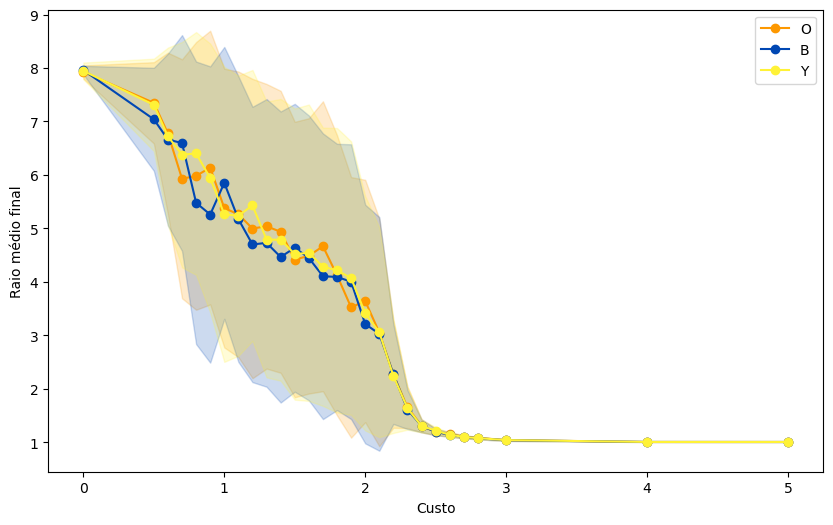

In [14]:
ultima_geracao = df_processed[df_processed["t"] == df_processed["t"].max()]
ultima_geracao

cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

plt.figure(figsize=(10, 6))
plt.plot(ultima_geracao["custo"], ultima_geracao["r_O_mean"], label="O", color=cores["O"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["r_O_mean"] - ultima_geracao["r_O_std"],
                 ultima_geracao["r_O_mean"] + ultima_geracao["r_O_std"],
                 color=cores["O"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["r_B_mean"], label="B", color=cores["B"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["r_B_mean"] - ultima_geracao["r_B_std"],
                 ultima_geracao["r_B_mean"] + ultima_geracao["r_B_std"],
                 color=cores["B"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["r_Y_mean"], label="Y", color=cores["Y"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["r_Y_mean"] - ultima_geracao["r_Y_std"],
                 ultima_geracao["r_Y_mean"] + ultima_geracao["r_Y_std"],
                 color=cores["Y"], alpha=0.2)
plt.xlabel("Custo")
plt.ylabel("Raio médio final")
plt.legend()
plt.savefig("C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/matriz_razao_2/custo_raio.png")
plt.show()

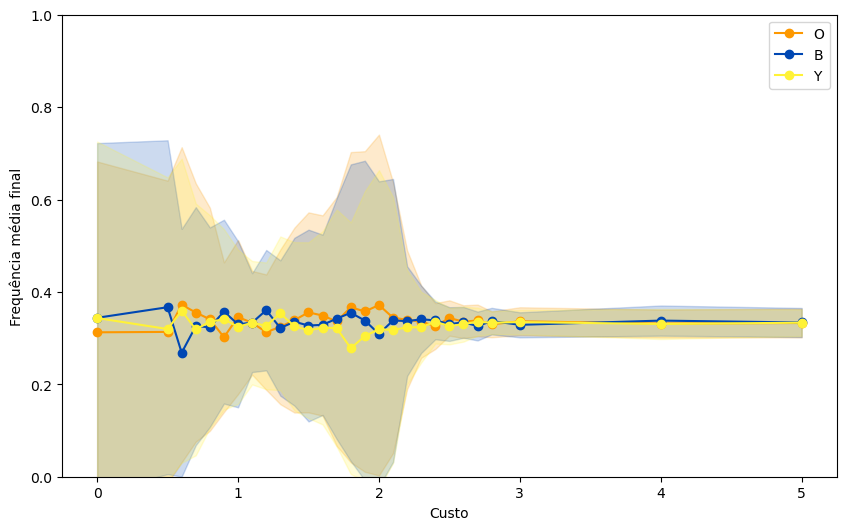

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(ultima_geracao["custo"], ultima_geracao["freq_O_mean"], label="O", color=cores["O"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["freq_O_mean"] - ultima_geracao["freq_O_std"],
                 ultima_geracao["freq_O_mean"] + ultima_geracao["freq_O_std"],
                 color=cores["O"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["freq_B_mean"], label="B", color=cores["B"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["freq_B_mean"] - ultima_geracao["freq_B_std"],
                 ultima_geracao["freq_B_mean"] + ultima_geracao["freq_B_std"],
                 color=cores["B"], alpha=0.2)
plt.plot(ultima_geracao["custo"], ultima_geracao["freq_Y_mean"], label="Y", color=cores["Y"], marker='o')
plt.fill_between(ultima_geracao["custo"],
                 ultima_geracao["freq_Y_mean"] - ultima_geracao["freq_Y_std"],
                 ultima_geracao["freq_Y_mean"] + ultima_geracao["freq_Y_std"],
                 color=cores["Y"], alpha=0.2)
plt.xlabel("Custo")
plt.ylabel("Frequência média final")
plt.ylim(0, 1)
plt.legend()
plt.savefig("C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/matriz_razao_2/custo_freq.png")
plt.show()

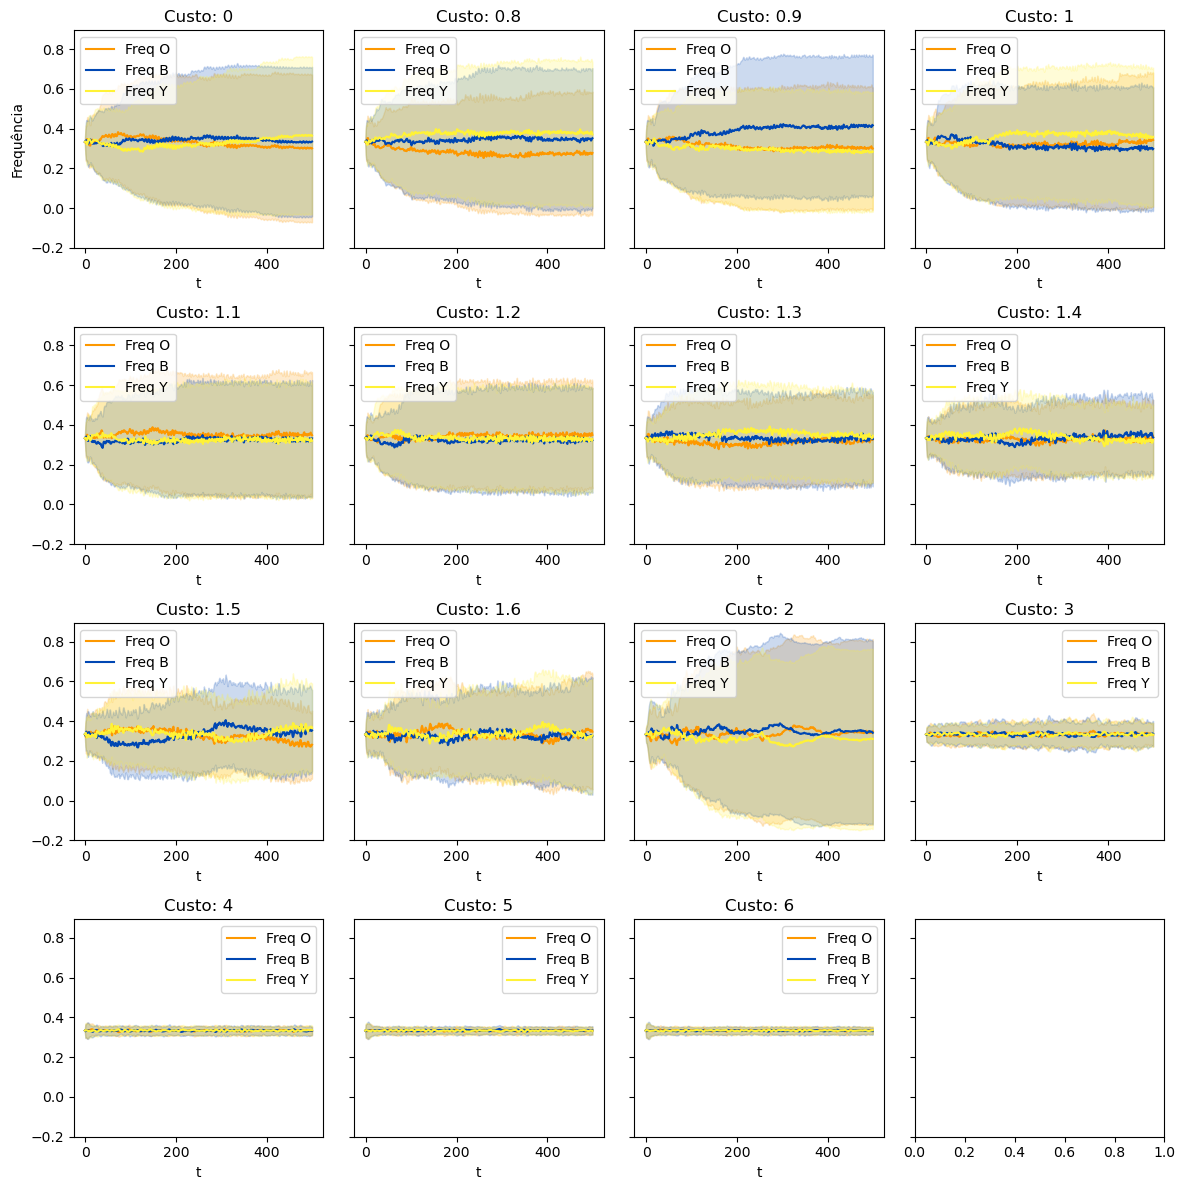

In [10]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharey=True)

for idx, c in enumerate(custo):
    ax = axes[idx//4, idx%4]
    df_c = df_processed[df_processed["custo"] == c]
    for cor in ["O", "B", "Y"]:
        ax.plot(df_c["t"], df_c[f"freq_{cor}_mean"], label=f"Freq {cor}", color=cores[cor])
        ax.fill_between(df_c["t"],
                        df_c[f"freq_{cor}_mean"] - df_c[f"freq_{cor}_std"],
                        df_c[f"freq_{cor}_mean"] + df_c[f"freq_{cor}_std"],
                        color=cores[cor], alpha=0.2)
    ax.set_title(f"Custo: {c}")
    ax.set_xlabel("t")
    if idx == 0:
        ax.set_ylabel("Frequência")
    ax.legend()

plt.tight_layout()
plt.savefig("C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/custo_freq_grid.png")
plt.show()

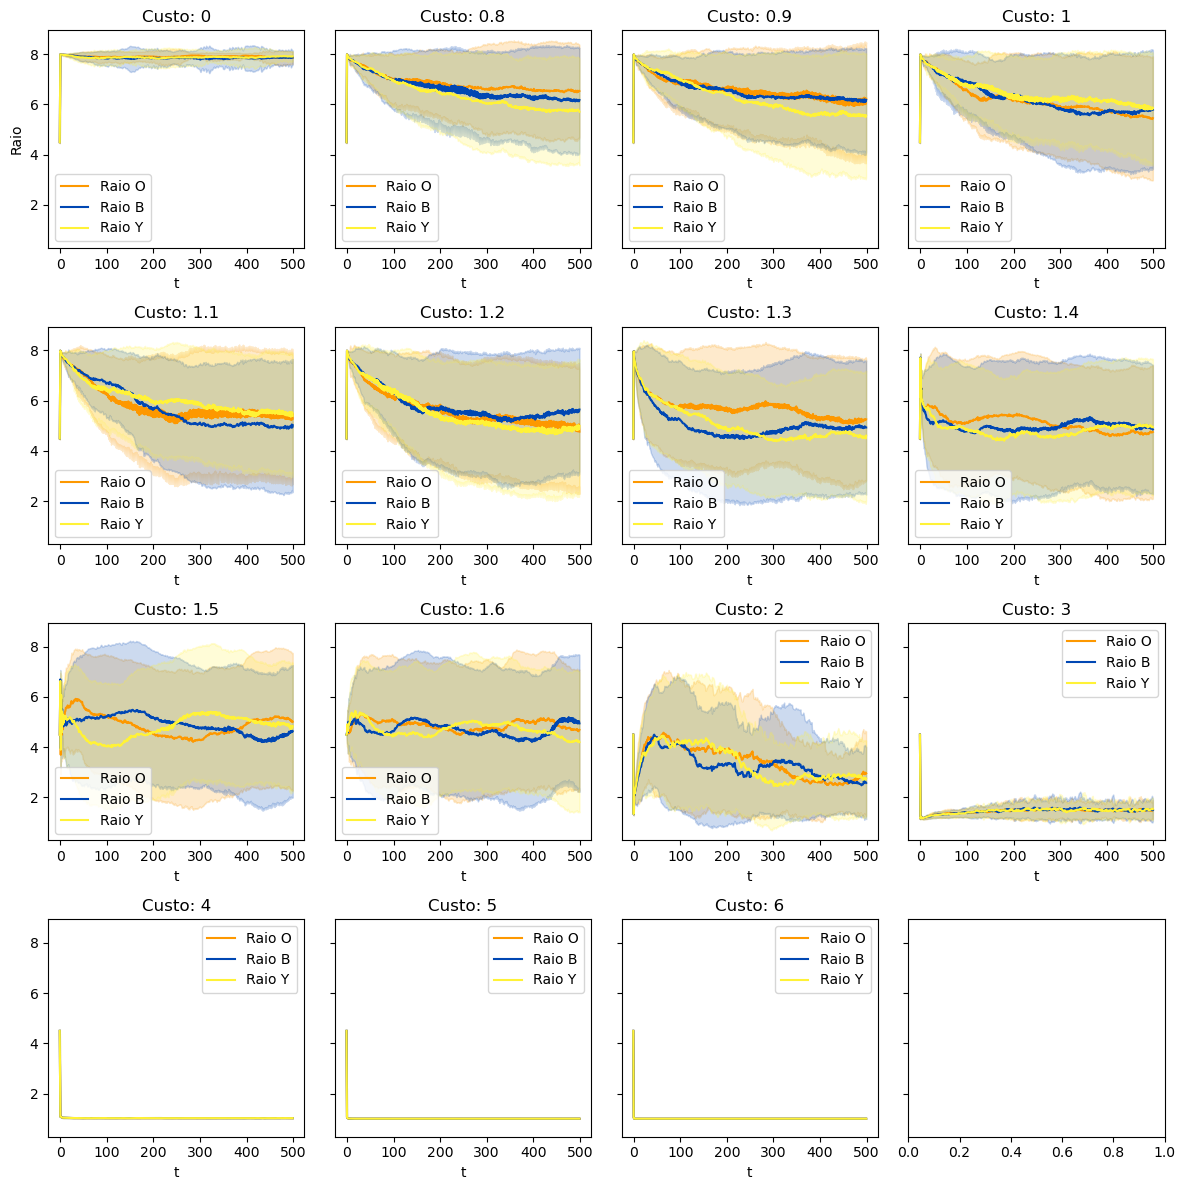

In [11]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharey=True)

for idx, c in enumerate(custo):
    ax = axes[idx//4, idx%4]
    df_c = df_processed[df_processed["custo"] == c]
    for cor in ["O", "B", "Y"]:
        ax.plot(df_c["t"], df_c[f"r_{cor}_mean"], label=f"Raio {cor}", color=cores[cor])
        ax.fill_between(df_c["t"],
                        df_c[f"r_{cor}_mean"] - df_c[f"r_{cor}_std"],
                        df_c[f"r_{cor}_mean"] + df_c[f"r_{cor}_std"],
                        color=cores[cor], alpha=0.2)
    ax.set_title(f"Custo: {c}")
    ax.set_xlabel("t")
    if idx == 0:
        ax.set_ylabel("Raio")
    ax.legend()

plt.tight_layout()
plt.savefig("C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/raio_evolutivo/custo_raio_grid.png")
plt.show()